# This notebook contains:
* Hovmöller diagrams of surface energy budget variables

In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
import sys
import matplotlib
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import metpy.calc as mpcalc
import pandas as pd
import os
import glob
from datetime import datetime
import seaborn as sns
import xarray as xr
from shapely import Polygon
import geopandas as gpd

/scratch/q90/ac9768/tmp/ipykernel_584517/2989713882.py:20: DeprecationWarning: Shapely 2.0 is installed, but because PyGEOS is also installed, GeoPandas still uses PyGEOS by default. However, starting with version 0.14, the default will switch to Shapely. To force to use Shapely 2.0 now, you can either uninstall PyGEOS or set the environment variable USE_PYGEOS=0. You can do this before starting the Python process, or in your code before importing geopandas:

import os
os.environ['USE_PYGEOS'] = '0'
import geopandas

In the next release, GeoPandas will switch to using Shapely by default, even if PyGEOS is installed. If you only have PyGEOS installed to get speed-ups, this switch should be smooth. However, if you are using PyGEOS directly (calling PyGEOS functions on geometries from GeoPandas), this will then stop working and you are encouraged to migrate from PyGEOS to Shapely 2.0 (https://shapely.readthedocs.io/en/latest/migration_pygeos.html).
  import geopandas as gpd


In [2]:
# open netcdf files created in BA_variable-to-netcdf notebook
# mean over radar domain
barra_towns = xr.open_dataset("/home/563/ac9768/GBR/barra-2/barra-2_850hPa_winds_townsville.nc", engine="h5netcdf",chunks="auto")
barra_cairns = xr.open_dataset("/home/563/ac9768/GBR/barra-2/barra-2_850hPa_winds_cairns.nc", engine="h5netcdf",chunks="auto")
barra_willis = xr.open_dataset("/home/563/ac9768/GBR/barra-2/barra-2_850hPa_winds_willis_island.nc", engine="h5netcdf",chunks="auto")
barra_towns_rad = xr.open_dataset("/home/563/ac9768/GBR/barra-2/barra-2_sfc-energy-budget_towns.nc", engine="h5netcdf",chunks="auto")
barra_cairns_rad = xr.open_dataset("/home/563/ac9768/GBR/barra-2/barra-2_sfc-energy-budget_cairns.nc", engine="h5netcdf",chunks="auto")
barra_willis_rad = xr.open_dataset("/home/563/ac9768/GBR/barra-2/barra-2_sfc-energy-budget_willis.nc", engine="h5netcdf",chunks="auto")

In [3]:
def regime(barra_site,deg1,deg2,variable_ds,ne=None,all_winds=None):
    winds = barra_site.wind_dir.compute()
    if ne==True:
        winds_dir = winds[(winds>=deg1)&(winds<=deg2)]
    else:
        winds_dir = winds[(winds>deg1)&(winds<=deg2)]
    if all_winds==True:
        winds_dir = winds
    else:
        pass
    # now that the regime composite times have been defined, calculate the diurnal mean of variable in question 
    
    regime = variable_ds.sel(time=winds_dir.time.values,method='nearest')
    mean_values = regime.groupby(regime.time.dt.hour).mean(dim='time')
    # shift from utc to aest
    aest = np.roll(mean_values,shift=10,axis=0)
    # for plotting, double array to show 48 hours
    double = np.concatenate([aest,aest]) 
    return double

In [4]:
# from above function calc regime mean for variable: regime(barra_site,deg1,deg2,variable_ds,ne=None,all_winds=None)
sfc_ne_dwSW = regime(barra_cairns,0,90,barra_cairns_rad.sfc_dw_SW,ne=True,all_winds=False)
sfc_se_dwSW = regime(barra_cairns,90,180,barra_cairns_rad.sfc_dw_SW,ne=False,all_winds=False)
sfc_sw_dwSW = regime(barra_cairns,180,270,barra_cairns_rad.sfc_dw_SW,ne=False,all_winds=False)
sfc_nw_dwSW = regime(barra_cairns,270,360,barra_cairns_rad.sfc_dw_SW,ne=False,all_winds=False)

sfc_ne_uwSW = regime(barra_cairns,0,90,barra_cairns_rad.sfc_uw_SW,ne=True,all_winds=False)
sfc_se_uwSW = regime(barra_cairns,90,180,barra_cairns_rad.sfc_uw_SW,ne=False,all_winds=False)
sfc_sw_uwSW = regime(barra_cairns,180,270,barra_cairns_rad.sfc_uw_SW,ne=False,all_winds=False)
sfc_nw_uwSW = regime(barra_cairns,270,360,barra_cairns_rad.sfc_uw_SW,ne=False,all_winds=False)

sfc_ne = sfc_ne_dwSW - sfc_ne_uwSW
sfc_se = sfc_se_dwSW - sfc_se_uwSW
sfc_sw = sfc_sw_dwSW - sfc_sw_uwSW
sfc_nw = sfc_nw_dwSW - sfc_nw_uwSW

In [17]:
sfc_ne.max()

822.198911516854

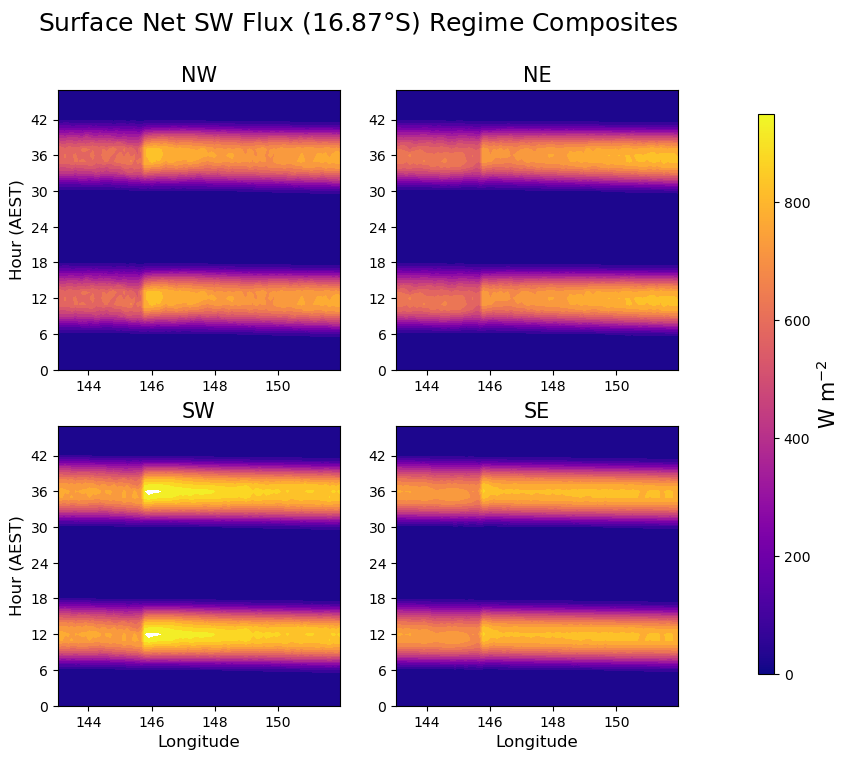

In [ ]:
def plot_barra_variables(barra_variable,level,cmap,scm,ne,se,sw,nw,cbar_label,title):
    fig, ax = plt.subplots(2,2,figsize=(8,8))
    fig.patch.set_facecolor('white')
    levels = level
    ax[0,1].contourf(barra_variable.lon,np.arange(0,48,1),ne,levels=levels,cmap=cmap)
    ax[1,1].contourf(barra_variable.lon,np.arange(0,48,1),se,levels=levels,cmap=cmap)
    ax[1,0].contourf(barra_variable.lon,np.arange(0,48,1),sw,levels=levels,cmap=cmap)
    ax[0,0].contourf(barra_variable.lon,np.arange(0,48,1),nw,levels=levels,cmap=cmap)

    # for colorbar plotting
    cax = fig.add_axes([1, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
    # # Create a colorbar using the ScalarMappable from one of the subplots
    sm = plt.cm.ScalarMappable(cmap=scm)
    sm.set_array(levels)  # You need to set an array for the ScalarMappable
    cbar = plt.colorbar(sm, cax=cax)
    cbar.set_label(cbar_label,fontsize=15)
    yticks = np.arange(0,48,6)
    ax[0,1].set_yticks(yticks)
    ax[1,1].set_yticks(yticks)
    ax[1,0].set_yticks(yticks)
    ax[0,0].set_yticks(yticks)
    
    ax[0,0].set_ylabel('Hour (AEST)',fontsize=12)
    ax[1,0].set_ylabel('Hour (AEST)',fontsize=12)
    ax[1,0].set_xlabel('Longitude',fontsize=12)
    ax[1,1].set_xlabel('Longitude',fontsize=12)
    
    ax[0,1].set_title("NE",fontsize=15)
    ax[1,1].set_title("SE",fontsize=15)
    ax[1,0].set_title("SW",fontsize=15)
    ax[0,0].set_title("NW",fontsize=15)
    fig.suptitle(title+' Regime Composites',fontsize=18)
    return
plot_barra_variables(barra_cairns_rad,np.arange(0,1000,50),"plasma",plt.cm.plasma,sfc_ne,sfc_se,sfc_sw,sfc_nw,'W m$^{-2}$','Surface Net SW Flux (16.87$\degree$S)')
